# Data Preprocessing and Modeling

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0275 - val_loss: 0.0030
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - val_loss: 0.0030
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0017 - val_loss: 0.0024
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 0.0021
Epoch 12/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - val_lo

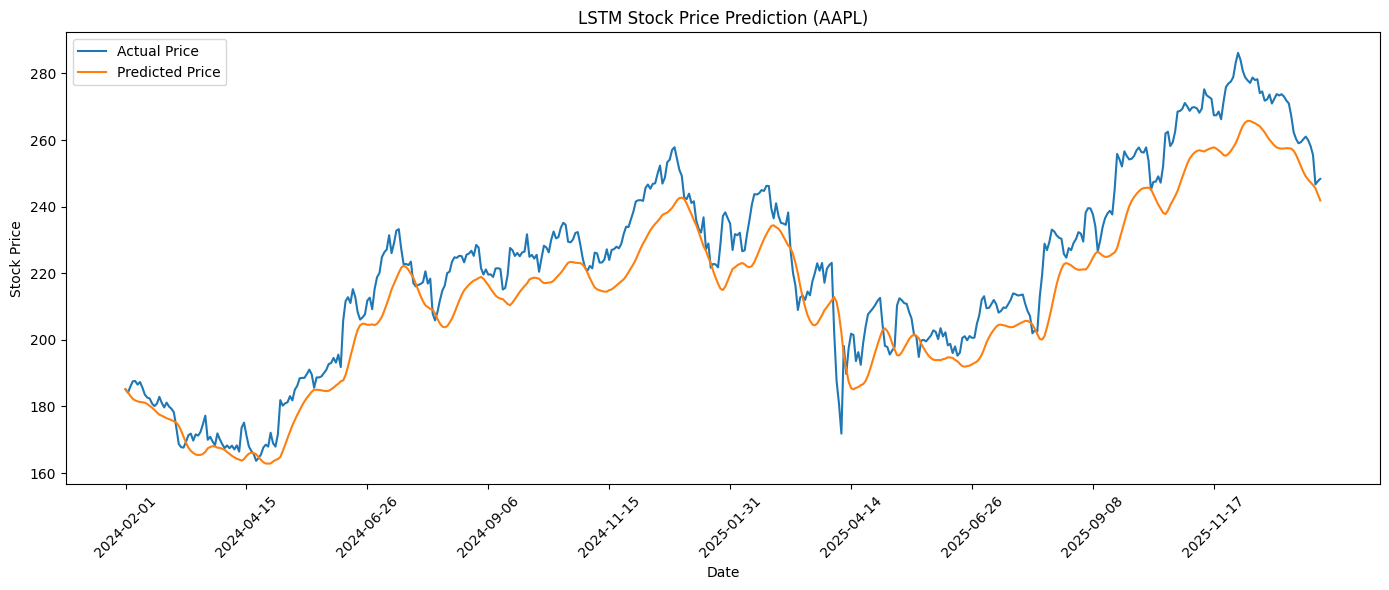

Prediction min/max: 162.81628 265.76337
Actual min/max: 163.66490173339844 286.19000244140625


In [5]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# Load dataset
df = pd.read_csv("./data/faang_stock_prices.csv")

# Sort data by company and date
df = df.sort_values(["Ticker", "Date"])


# Filter one company
company_df = df[df["Ticker"] == "AAPL"].copy()

# Sort by date
company_df = company_df.sort_values("Date")


# Use closing prices
data = company_df["Close"].values

# Store dates for plotting
dates = company_df["Date"].values


# Create sequences
window_size = 20

X = []
y = []

for i in range(len(data) - window_size):

    # Previous 20 days
    x_window = data[i:i+window_size]

    # Next day price
    y_value = data[i+window_size]

    # Store values
    X.append(x_window)
    y.append(y_value)


# Convert lists to arrays
X = np.array(X)
y = np.array(y)

# Match dates with target values
dates = dates[window_size:]


# Train/test split
split_index = int(len(X) * 0.8)

X_train = []
y_train = []

X_test = []
y_test = []

for i in range(len(X)):

    # First 80% for training
    if i < split_index:

        X_train.append(X[i])
        y_train.append(y[i])

    # Last 20% for testing
    else:

        X_test.append(X[i])
        y_test.append(y[i])


# Convert to arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

# Split dates for plotting
test_dates = dates[split_index:]


# Scale X values
x_scaler = MinMaxScaler()

# Reshape training data
X_train_reshaped = X_train.reshape(-1, 1)

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_reshaped)

# Reshape back
X_train_scaled = X_train_scaled.reshape(X_train.shape)

# Reshape testing data
X_test_reshaped = X_test.reshape(-1, 1)

# Scale testing data
X_test_scaled = x_scaler.transform(X_test_reshaped)

# Reshape back
X_test_scaled = X_test_scaled.reshape(X_test.shape)


# Scale y values
y_scaler = MinMaxScaler()

# Scale training targets
y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1, 1)
)

# Scale testing targets
y_test_scaled = y_scaler.transform(
    y_test.reshape(-1, 1)
)


# Build model
model = Sequential()

# LSTM layer
model.add(
    LSTM(
        64,
        input_shape=(20, 1)
    )
)

# Dropout layer
model.add(Dropout(0.2))

# Output layer
model.add(Dense(1))

# Compile model
model.compile(
    optimizer="adam",
    loss="mse"
)

# Show model summary
model.summary()


# Train model
history = model.fit(

    X_train_scaled,
    y_train_scaled,

    epochs=20,
    batch_size=32,

    validation_data=(
        X_test_scaled,
        y_test_scaled
    )
)


# Make predictions
predictions = model.predict(X_test_scaled)


# Convert predictions back to real prices
predictions = y_scaler.inverse_transform(predictions)

y_test_actual = y_scaler.inverse_transform(
    y_test_scaled
)


# Plot results
plt.figure(figsize=(14,6))

# Actual stock prices
plt.plot(
    test_dates,
    y_test_actual,
    label="Actual Price"
)

# Predicted stock prices
plt.plot(
    test_dates,
    predictions,
    label="Predicted Price"
)

# Graph title and labels
plt.title("LSTM Stock Price Prediction (AAPL)")
plt.xlabel("Date")
plt.ylabel("Stock Price")

# Show fewer dates on x-axis
plt.xticks(test_dates[::50], rotation=45)

# Show legend
plt.legend()

# Adjust spacing
plt.tight_layout()

# Display graph
plt.show()


# Print value ranges
print(
    "Prediction min/max:",
    predictions.min(),
    predictions.max()
)

print(
    "Actual min/max:",
    y_test_actual.min(),
    y_test_actual.max()
)